# Модели регрессии на данных различного рода

## Требования для сдачи лабораторной работы:
1. Создать синтетические данные
2. Обучить линейную регрессионную модель на синтетических данных
3. Обучить полиномиальную регрессионную модель на синтетических данных
3. Добиться адекватных результатов модели
4. Выводы по обучению на синтетических данных
5. Выбор набора данных для обучения моделей регресии
6. Предварительная обработка датасета
7. Обучение модели логистической регрессии
8. Улучшение качества модели
9. Вывод после обучения на реальных данных
10. Выбор альтернативной модели
11. Настройка гиперпараметров
12. Сравнение логистичкой регресии
13. Общие выводы

*Использовать бустинги, ансамбли и случайный лес нельзя.*

## Библиотеки

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PowerTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

Выбор темы для графиков MatPlotLib и plotly

In [2]:
plt.style.use('dark_background')

Объявление констант

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Вспомогательные функции и оформление

In [4]:
class FigureCounter:
    """Сквозная нумерация рисунков: figure_counter() возвращает целое."""
    def __init__(self) -> None:
        self.n = 0
    
    def __call__(self) -> int:
        self.n += 1
        return self.n

figure_counter = FigureCounter()


def score_model(model, X, y) -> dict:
    """Расчёт MAE, RMSE, R^2 и MAPE для регрессионной модели.

    MAE - средняя абсолютная ошибка, 
    RMSE - корень из средней квадратичной ошибки,
    R^2 - коэффициент детерминации, 
    MAPE - средняя абсолютная процентная ошибка.
    """
    pred = model.predict(X)
    return {
        'MAE':  mean_absolute_error(y, pred),
        'RMSE': root_mean_squared_error(y, pred),
        'R2':   r2_score(y, pred),
        'MAPE': mean_absolute_percentage_error(y, pred),
    }


def metrics_row(model, X_train, y_train, X_val, y_val, name: str) -> dict:
    """Строка для сравнительной таблицы: одна модель, две выборки.
    
    MAE - средняя абсолютная ошибка, 
    RMSE - корень из средней квадратичной ошибки,
    R^2 - коэффициент детерминации, 
    MAPE - средняя абсолютная процентная ошибка.
    """
    tr = score_model(model, X_train, y_train)
    va = score_model(model, X_val, y_val)
    return {
        'Модель': name,
        'MAE (train)': tr['MAE'],   'MAE (val)':  va['MAE'],
        'RMSE (train)': tr['RMSE'], 'RMSE (val)': va['RMSE'],
        'R2 (train)':  tr['R2'],    'R2 (val)':   va['R2'],
        'MAPE (train)': tr['MAPE'], 'MAPE (val)': va['MAPE'],
    }


## Часть 1. Синтетические данные

Цель синтетического эксперимента — на простой одномерной задаче увидеть, как линейная регрессия проигрывает полиномиальной, как регуляризация удерживает коэффициенты от взрывного роста и как ведут себя предсказания за пределами обучающего отрезка.


### 1.1. Генерация нелинейной зависимости

Возьмём зависимость с линейной частью и двумя синусоидами разных частот:

$$y = 0{,}5\,x + 3\sin(2x) + \sin(5x) + \varepsilon,\qquad \varepsilon \sim \mathcal N(0, \sigma^2), \sigma = 0{,}4.$$

Линейная часть отвечает за общий наклон, синусы создают локальные колебания, шум – реалистичность. Аргумент $x$ задаём на отрезке $[-4,\ 4]$; шагов берём 400, чтобы кривая была плотно покрыта точками.


In [5]:
def synthetic_target(x: np.ndarray, noise_std: float = 0.4) -> np.ndarray:
    return 0.5 * x + 3 * np.sin(2 * x) + np.sin(5 * x) + np.random.normal(0, noise_std, size=x.shape)

x_full = np.linspace(-4.0, 4.0, 400)
y_full = synthetic_target(x_full)

# Истинная функция без шума — нужна для сравнения предсказаний с «правильным» ответом
def synthetic_truth(x: np.ndarray) -> np.ndarray:
    return 0.5 * x + 3 * np.sin(2 * x) + np.sin(5 * x)

print(f"Размер выборки: {x_full.shape[0]} точек, диапазон x: [{x_full.min():.1f}, {x_full.max():.1f}]")
print(f"Диапазон y: [{y_full.min():.2f}, {y_full.max():.2f}]")

Размер выборки: 400 точек, диапазон x: [-4.0, 4.0]
Диапазон y: [-5.90, 6.38]


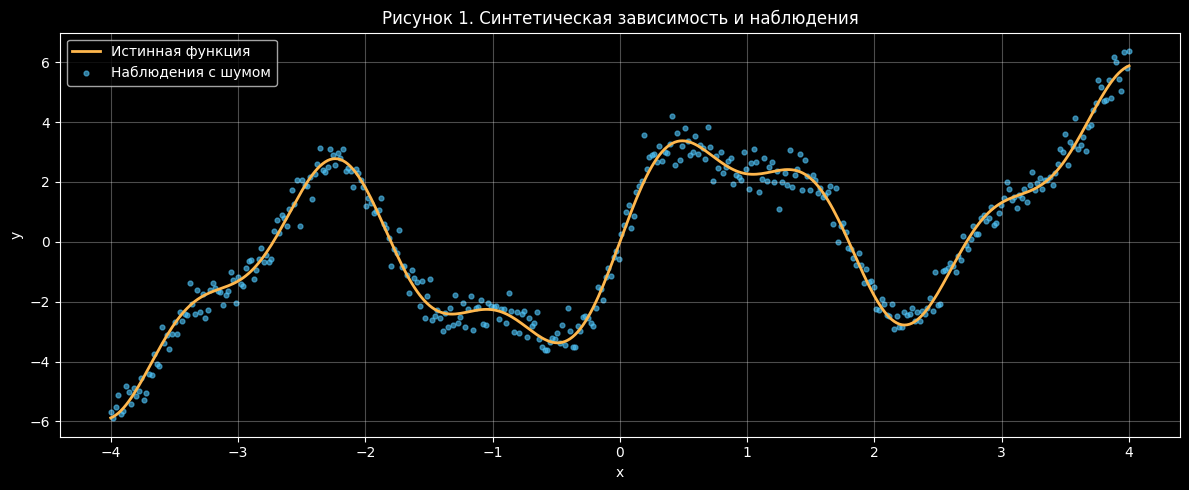

In [6]:
fig_n = figure_counter()
plt.figure(figsize=(12, 5))
plt.plot(x_full, synthetic_truth(x_full), color='#FFB74D', linewidth=2, label='Истинная функция')
plt.scatter(x_full, y_full, s=12, color='#4FC3F7', alpha=0.6, label='Наблюдения с шумом')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Рисунок {fig_n}. Синтетическая зависимость и наблюдения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Кривая вышла интересной: имеет заметные выбросы на тех формах графика, где горбы чаще. Явно не линейна.

### 1.2. Разделение на обучающую и валидационную выборки

Разбиение 75 / 25. Перед делением точки перемешиваются — это важно: если оставить их по возрастанию $x$, валидация попадёт в один край интервала, и оценка качества будет смещённой.


In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_full.reshape(-1, 1), y_full,
    test_size=0.25,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f"Размер обучающей выборки: {x_train.shape[0]}")
print(f"Размер валидационной выборки: {x_val.shape[0]}")

Размер обучающей выборки: 300
Размер валидационной выборки: 100


### 1.3. Линейная регрессия как нижняя граница

Прежде чем подключать полиномы, оценим, насколько прямая может описать данные. Это нужно как точка отсчёта: всё, что не помещается в прямую, — это «нелинейность», которую полиномам предстоит подобрать.


In [8]:
lr_baseline = LinearRegression().fit(x_train, y_train)

baseline_row = metrics_row(lr_baseline, x_train, y_train, x_val, y_val, name='Линейная (степень 1)')
pd.DataFrame([baseline_row]).round(3)

,Модель,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val),MAPE (train),MAPE (val)
0,Линейная (степень 1),1.887,2.038,2.201,2.355,0.245,0.279,1.299,1.122


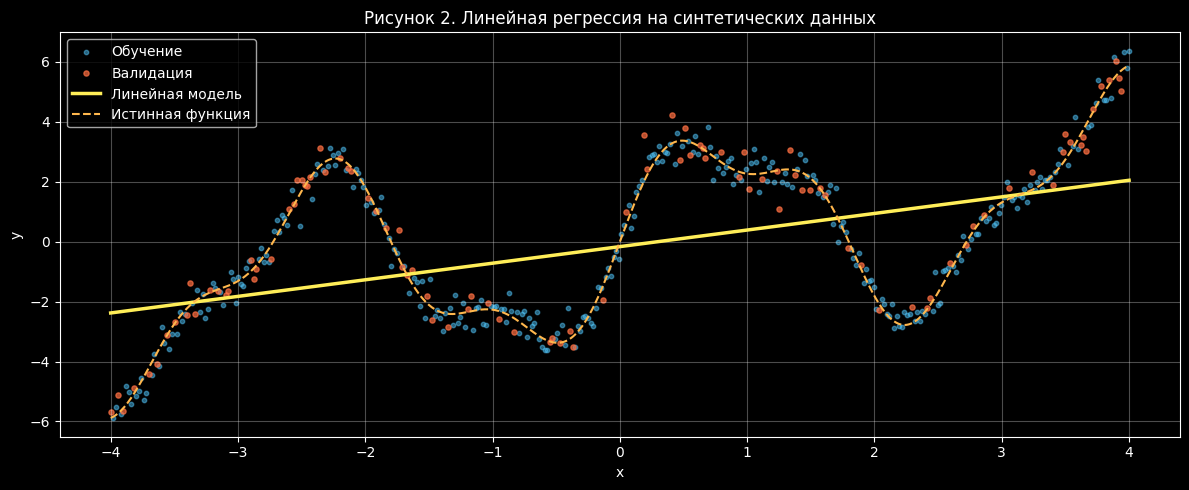

In [9]:
fig_n = figure_counter()
x_grid = np.linspace(-4.0, 4.0, 600).reshape(-1, 1)

plt.figure(figsize=(12, 5))
plt.scatter(x_train.ravel(), y_train, s=10, color='#4FC3F7', alpha=0.5, label='Обучение')
plt.scatter(x_val.ravel(), y_val, s=14, color='#FF7043', alpha=0.7, label='Валидация')
plt.plot(x_grid.ravel(), lr_baseline.predict(x_grid), color='#FFEE58', linewidth=2.5, label='Линейная модель')
plt.plot(x_grid.ravel(), synthetic_truth(x_grid.ravel()), '--', color='#FFB74D', linewidth=1.5, label='Истинная функция')
plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Рисунок {fig_n}. Линейная регрессия на синтетических данных')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

Линейная модель улавливает общий наклон $0{,}5\,x$ и игнорирует обе синусоиды: на графике прямая идёт сквозь центр колебаний, оставляя систематические остатки сверху и снизу. По метрикам это видно как низкий $R^2$ и высокий RMSE — простой прямой недостаточно.


### 1.4. Полиномиальные признаки разных степеней

Будем расширять признак $x$ до $\{x, x^2, \dots, x^d\}$ и обучать на этом обычную линейную регрессию. Перебираем степени $d \in \{1, 2, 3, 5, 7, 9, 11, 13, 15\}$: важно увидеть, как метрики на обучении продолжают расти, а на валидации в какой-то момент сваливаются — это и есть переобучение.


In [10]:
def make_poly_pipeline(degree: int, regressor=None) -> Pipeline:
    if regressor is None:
        regressor = LinearRegression()
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg',  regressor),
    ])


degrees_grid = [1, 2, 3, 5, 7, 9, 11, 13, 15]
poly_runs = []
poly_models = {}

for d in degrees_grid:
    model = make_poly_pipeline(d).fit(x_train, y_train)
    row = metrics_row(model, x_train, y_train, x_val, y_val, name=f'OLS, deg={d}')
    row['Степень'] = d
    poly_runs.append(row)
    poly_models[d] = model

poly_df = pd.DataFrame(poly_runs).set_index('Степень')[['MAE (train)', 'MAE (val)', 'RMSE (train)', 'RMSE (val)', 'R2 (train)', 'R2 (val)']]
poly_df.round(3)

,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val)
Степень,,,,,,
1,1.887,2.038,2.201,2.355,0.245,0.279
2,1.887,2.039,2.201,2.356,0.246,0.279
3,1.755,1.794,2.062,2.131,0.337,0.410
5,1.388,1.442,1.606,1.684,0.598,0.631
7,0.845,0.901,0.997,1.082,0.845,0.848
9,0.602,0.621,0.713,0.757,0.921,0.925
11,0.597,0.618,0.711,0.751,0.921,0.927
13,0.539,0.551,0.669,0.719,0.930,0.933
15,0.542,0.556,0.659,0.715,0.932,0.933


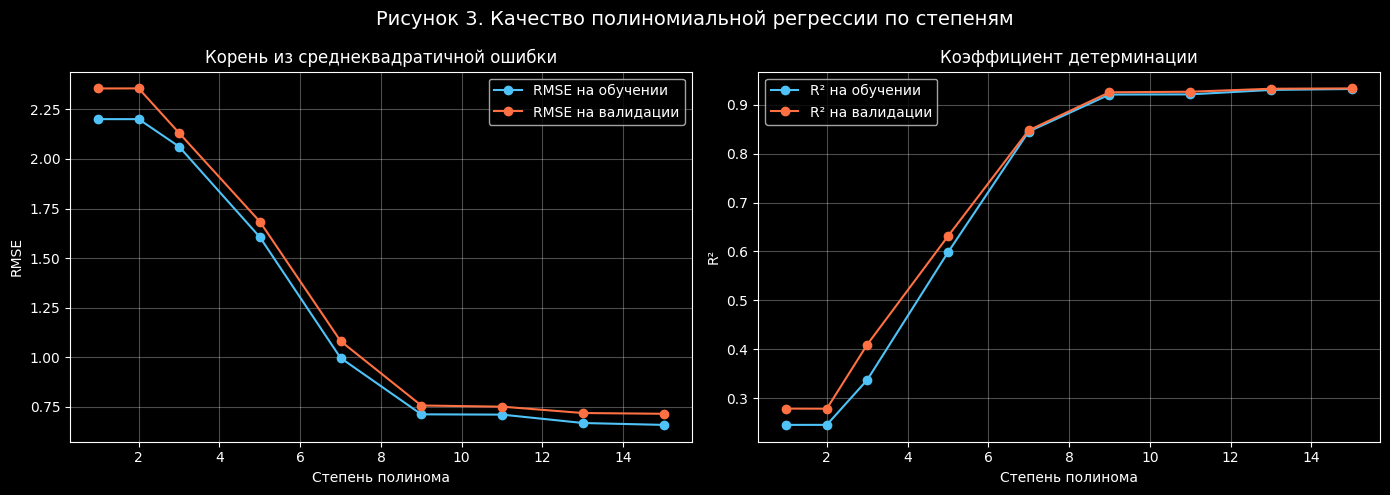

In [11]:
fig_n = figure_counter()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Рисунок {fig_n}. Качество полиномиальной регрессии по степеням', fontsize=14)

axes[0].plot(poly_df.index, poly_df['RMSE (train)'], marker='o', label='RMSE на обучении', color='#4FC3F7')
axes[0].plot(poly_df.index, poly_df['RMSE (val)'],   marker='o', label='RMSE на валидации', color='#FF7043')
axes[0].set_xlabel('Степень полинома'); axes[0].set_ylabel('RMSE')
axes[0].set_title('Корень из среднеквадратичной ошибки')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(poly_df.index, poly_df['R2 (train)'], marker='o', label='R² на обучении', color='#4FC3F7')
axes[1].plot(poly_df.index, poly_df['R2 (val)'],   marker='o', label='R² на валидации', color='#FF7043')
axes[1].set_xlabel('Степень полинома'); axes[1].set_ylabel('R²')
axes[1].set_title('Коэффициент детерминации')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

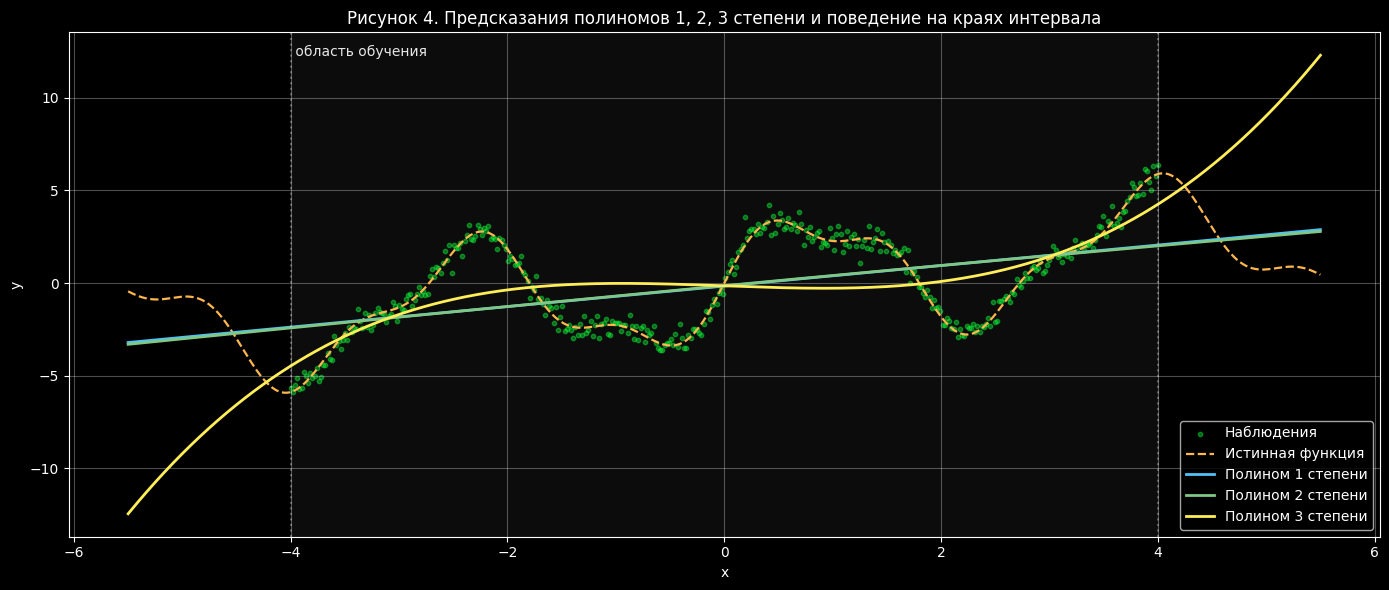

In [12]:
def plot_poly_predictions(poly_models: dict, degrees_grid: list, x_full: np.ndarray, y_full: np.ndarray) -> None:
    '''Построение графика предсказаний полиномиальных моделей и сравнение с истинной функцией.'''
    fig_n = figure_counter()
    x_ext = np.linspace(-5.5, 5.5, 800).reshape(-1, 1)  # расширенная сетка для демонстрации экстраполяции

    plt.figure(figsize=(14, 6))
    plt.scatter(x_full, y_full, s=10, color="#00FF2F", alpha=0.4, label='Наблюдения')
    plt.plot(x_ext.ravel(), synthetic_truth(x_ext.ravel()), '--', color='#FFB74D', linewidth=1.6, label='Истинная функция')

    for d, color in zip(degrees_grid[:4], ['#4FC3F7', '#81C784', '#FFEE58', '#EF5350']):
        plt.plot(x_ext.ravel(), poly_models[d].predict(x_ext), color=color, linewidth=2, label=f'Полином {d} степени')

    plt.axvspan(-4, 4, color='#FFFFFF', alpha=0.05)
    plt.axvline(-4, color='#FFFFFF', alpha=0.3, linestyle=':')
    plt.axvline( 4, color='#FFFFFF', alpha=0.3, linestyle=':')
    plt.text(-4, plt.ylim()[1]*0.95, ' область обучения ', color='#FFFFFF', alpha=0.9, va='top')

    plt.xlabel('x'); plt.ylabel('y')
    plt.title(f'Рисунок {fig_n}. Предсказания полиномов {", ".join(map(str, degrees_grid[:4]))} степени и поведение на краях интервала')
    plt.legend(loc='lower right'); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

# Смотрим кривые 1, 2 и 3 степени
plot_poly_predictions(poly_models, degrees_grid[:3], x_full, y_full)

Полином 3 степени уже выходит из ОДЗ за областью обучающих данных.

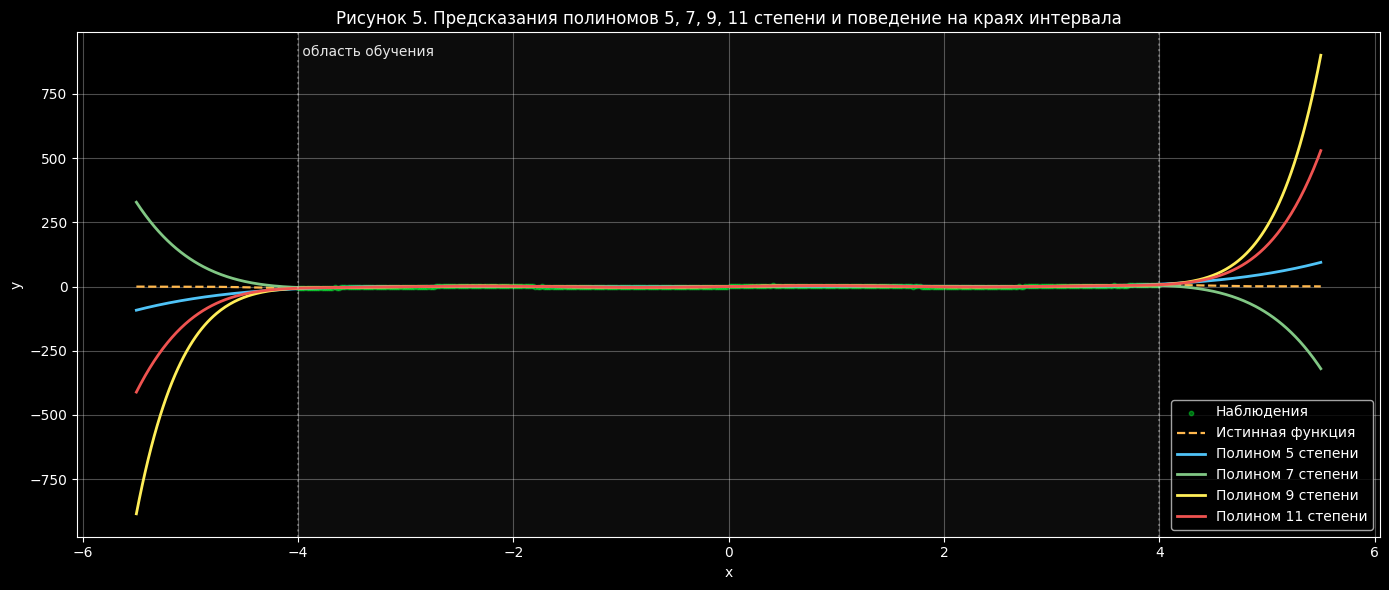

In [13]:
# Смотрим кривые 5, 7, 9 и 11 степени
plot_poly_predictions(poly_models, degrees_grid[3:7], x_full, y_full)

Из-за масштаба истинная функция стала походить на линейную. Наблюдения не различимы.

Отметим необычное поведение 11 степени – менее вытянута по сравнению с 9 степенью.

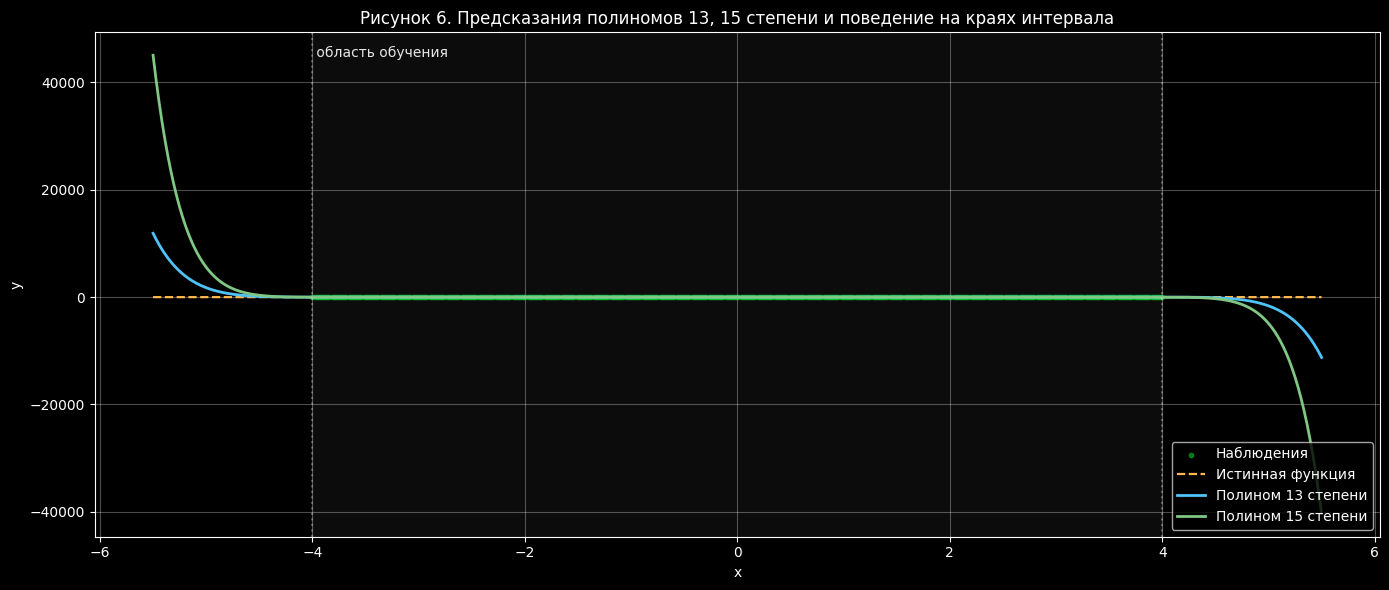

In [14]:
# Смотрим кривые 13 и 15 степени
plot_poly_predictions(poly_models, degrees_grid[7:9], x_full, y_full)

Отклонение от целевой функции исчисляется тысячами для 13 и 15 степени на продленном интервале.

### 1.5. Регуляризация: Ridge и Lasso

Ridge добавляет к функции потерь $\|\beta\|_2^2$ с весом $\alpha$, Lasso — $\|\beta\|_1$. Первый сжимает коэффициенты равномерно, второй умеет занулять часть.

Возьмём фиксированную степень $d = 13$ (одну из переобучающихся) и сравним три варианта: чистый МНК, Ridge с $\alpha = 1$ и Lasso с $\alpha = 0{,}01$.


In [15]:
fixed_degree = 13
reg_zoo = {
    'Метод наименьших квадратов':   LinearRegression(),
    f'Ridge, α=1.0':                Ridge(alpha=1.0),
    f'Lasso, α=0.01':               Lasso(alpha=0.01, max_iter=50_000),
}

reg_runs = []
reg_models = {}
for name, reg in reg_zoo.items():
    model = make_poly_pipeline(fixed_degree, regressor=reg).fit(x_train, y_train)
    reg_runs.append(metrics_row(model, x_train, y_train, x_val, y_val, name=name))
    reg_models[name] = model

pd.DataFrame(reg_runs).round(3)

/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.993889808033928e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.106e+02, tolerance: 1.925e-01
  model = cd_fast.enet_coordinate_descent(


,Модель,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val),MAPE (train),MAPE (val)
0,Метод наименьших квадратов,0.539,0.551,0.669,0.719,0.930,0.933,0.380,0.342
1,"Ridge, α=1.0",0.538,0.553,0.680,0.747,0.928,0.927,0.390,0.333
2,"Lasso, α=0.01",0.646,0.662,0.753,0.820,0.912,0.913,0.513,0.449


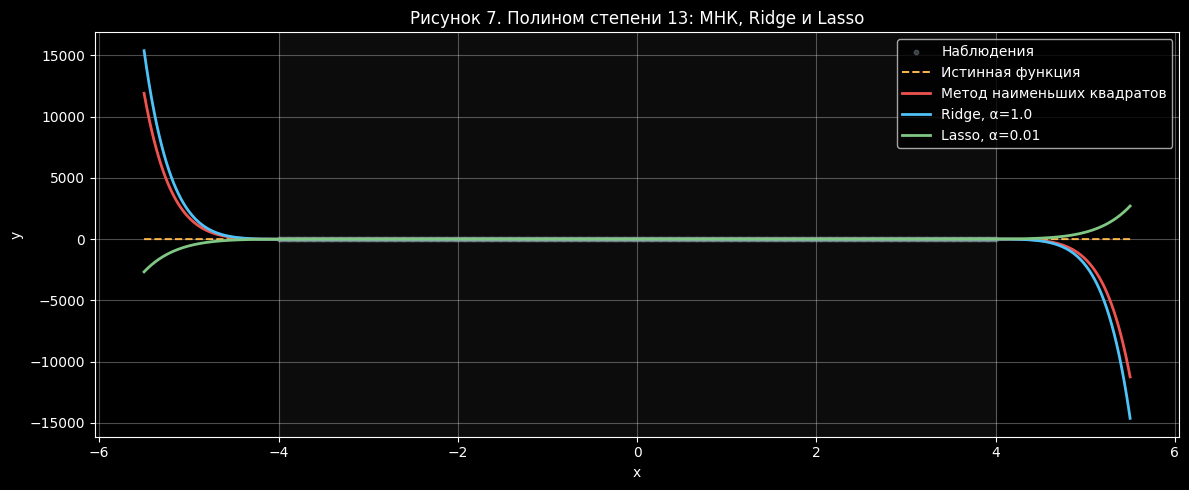

In [16]:
x_ext = np.linspace(-5.5, 5.5, 800).reshape(-1, 1)  # расширенная сетка для демонстрации экстраполяции
fig_n = figure_counter()
plt.figure(figsize=(12, 5))
plt.scatter(x_full, y_full, s=10, color='#90A4AE', alpha=0.35, label='Наблюдения')
plt.plot(x_ext.ravel(), synthetic_truth(x_ext.ravel()), '--', color='#FFB74D', linewidth=1.4, label='Истинная функция')

palette = {'Метод наименьших квадратов': '#EF5350', 'Ridge, α=1.0': '#4FC3F7', 'Lasso, α=0.01': '#81C784'}
for name, model in reg_models.items():
    plt.plot(x_ext.ravel(), model.predict(x_ext), color=palette[name], linewidth=2, label=name)

plt.axvspan(-4, 4, color='#FFFFFF', alpha=0.05)
plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Рисунок {fig_n}. Полином степени 13: МНК, Ridge и Lasso')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

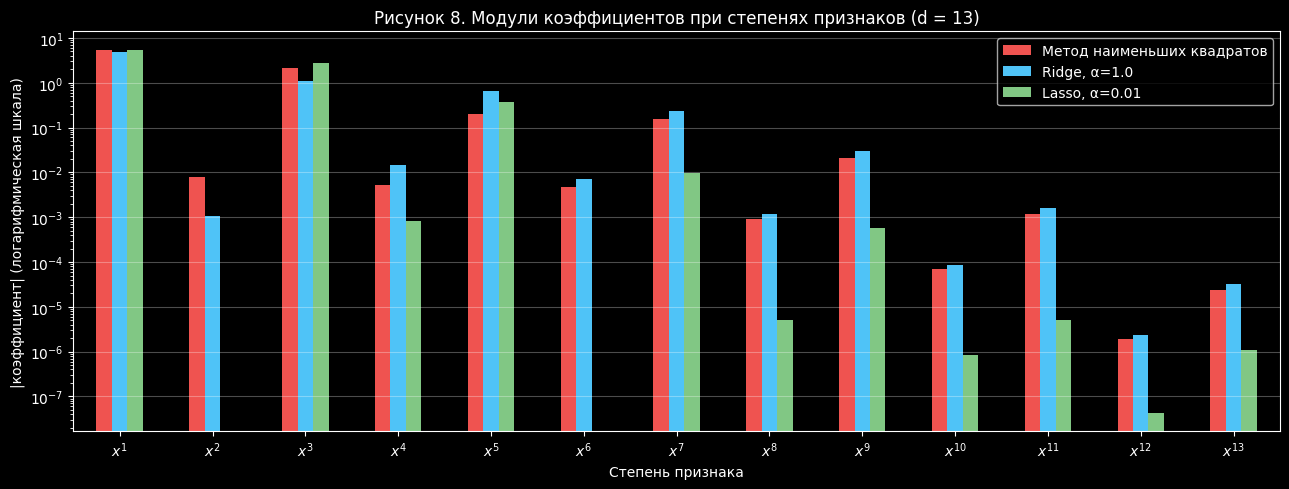

In [17]:
# Сравнение модулей коэффициентов: видно, как Lasso «гасит» часть степеней до нуля
fig_n = figure_counter()
coef_df = pd.DataFrame({
    name: np.abs(model.named_steps['reg'].coef_)
    for name, model in reg_models.items()
}, index=[f'$x^{{{i}}}$' for i in range(1, fixed_degree + 1)])

ax = coef_df.plot.bar(figsize=(13, 5), color=[palette[c] for c in coef_df.columns])
ax.set_yscale('log')
ax.set_ylabel('|коэффициент| (логарифмическая шкала)')
ax.set_xlabel('Степень признака')
ax.set_title(f'Рисунок {fig_n}. Модули коэффициентов при степенях признаков (d = 13)')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

На последнем рисунке видно артефакт: без регуляризации коэффициенты при высоких степенях достигают значений в сотни и тысячи, тогда как Ridge удерживает их в десятках, а Lasso часть признаков обнуляет. Высокие коэффициенты — это, по сути, индикатор того, что модель «трясёт» от малейшего изменения данных, и интерпретация теряет смысл.


### 1.6. Артефакты: переобучение, перегибы на краях, нестабильные коэффициенты

Сведём три ожидаемых проявления в одно место.

- **Переобучение.** RMSE на обучении продолжает падать с ростом степени, на валидации — ведёт себя немонотонно: на 11-й степени видно локальный рост, дальше снова небольшое снижение. Это не «улучшение», а подгонка под конкретные точки обучающей выборки.
- **Осцилляции на краях.** За пределами $[-4,\ 4]$ полином 15-й степени уходит резкими взмахами вверх и вниз, тогда как степень 3–5 на краях ведёт себя умеренно. Проявляется эффект Рунге: полиномиальная интерполяция становится неустойчивой вблизи краёв интервала.
- **Нестабильные коэффициенты.** Без регуляризации модули коэффициентов при $x^{13}$ и $x^{15}$ достигают десятки тысяч — это причина выбросов на краях, и сигнал, что предсказание чувствительно к мельчайшим изменениям данных.


### 1.7. Выводы по синтетическому эксперименту

- **Подходящая степень полинома.** На обучающем отрезке лучше всего себя ведут степени 5–9: RMSE на валидации стабильно ниже, а коэффициенты ещё не разгоняются. На 11-й степени появляется локальный рост RMSE — это уже подгонка под конкретные точки. У 13 и 15 численная ошибка на валидации иногда чуть меньше, но это видимая иллюзия: на краях обучающего диапазона предсказания резко взлетают.
- **Эффект Ridge и Lasso.** Регуляризация помогла на двух уровнях. Во-первых, она удержала коэффициенты при высоких степенях в разумных пределах: разница на пару порядков между OLS и Ridge видна на «Рисунке 6». Во-вторых, форма предсказаний за пределами $[-4,\ 4]$ становится спокойнее, без резких взмахов. Lasso дополнительно зануляет часть степеней, поэтому модель остаётся проще, но качество на этой задаче чуть слабее Ridge.
- **Поведение на краях.** «Горбы» синтетической функции и шум приводят к тому, что выбросов больше всего там, где наклон функции велик. Полиномы высоких степеней пытаются объяснить эти выбросы и в результате именно на краях разгоняются особенно сильно — это и есть эффект Рунге в чистом виде.
- **Артефакт нестабильных коэффициентов.** На Рисунке 8 видно, что без регуляризации $|\beta_{13}|, |\beta_{15}|$ в десятки раз превосходят коэффициенты Ridge при тех же степенях. Интерпретация таких коэффициентов бесполезна — они просто компенсируют друг друга в линейной комбинации.


## Часть 2. Реальные данные. California Housing

Дальше — реальный датасет на регрессию: медианная стоимость жилья по районам Калифорнии (выборка 1990 года, 20 640 строк, 8 числовых признаков). Целевая переменная — `MedHouseVal`, медианная цена дома в сотнях тысяч долларов. Ограничение: верхняя граница в датасете обрезана значением 5,0 (то есть 500 тысяч долларов США), это важный нюанс, который может проявится в остатках.


### 2.1. Загрузка и описание данных

In [18]:
X, y = fetch_california_housing(as_frame=True, return_X_y=True)
df_cal = X.copy()
df_cal['MedHouseVal'] = y
df_cal = pd.DataFrame.from_dict(df_cal)

print(f"Размерность: {df_cal.shape[0]} строк, {df_cal.shape[1]} столбцов (включая целевую переменную)")
print(f"Целевая переменная: MedHouseVal — медианная цена дома (в сотнях тысяч долларов США)")
df_cal.head()

Размерность: 20640 строк, 9 столбцов (включая целевую переменную)
Целевая переменная: MedHouseVal — медианная цена дома (в сотнях тысяч долларов США)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Проверка на дубликаты

In [19]:
df_cal[df_cal.duplicated()]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


Базовая статискика

In [20]:
df_cal.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [21]:
missing = df_cal.isna().sum()
print("Пропуски по столбцам:")
print(missing[missing > 0] if missing.sum() > 0 else "Нет пропущенных значений")

Пропуски по столбцам:
Нет пропущенных значений


### 2.2. Разведочный анализ распределений и корреляций

Два кратких графика: гистограммы признаков и тепловая карта корреляций. Это даст ориентир для дальнейших шагов.


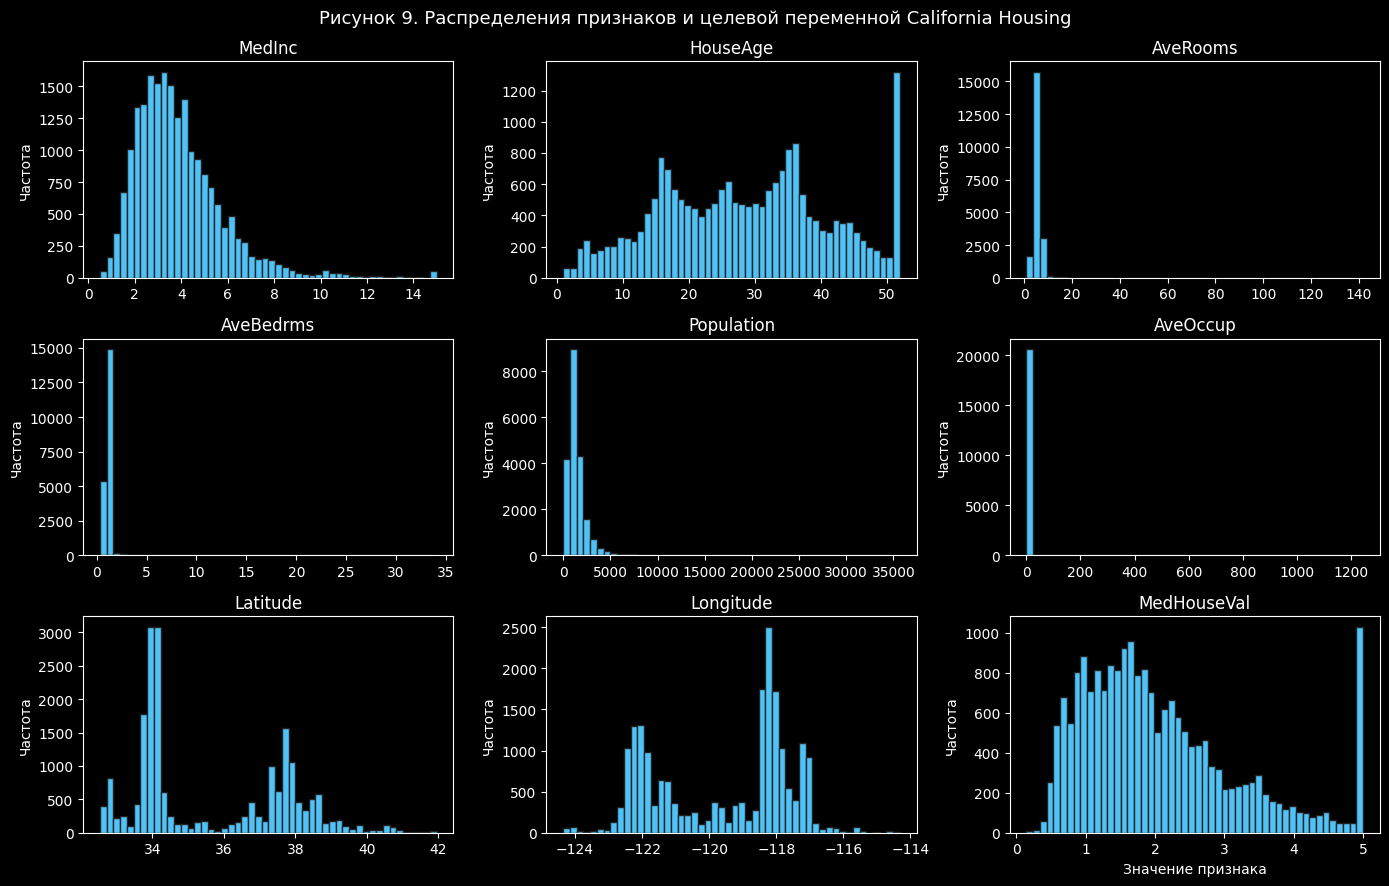

In [22]:
fig_n = figure_counter()
features = [c for c in df_cal.columns if c != 'MedHouseVal']

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
fig.suptitle(f'Рисунок {fig_n}. Распределения признаков и целевой переменной California Housing', fontsize=13)
for ax, col in zip(axes.flat, features + ['MedHouseVal']):
    ax.hist(df_cal[col], bins=50, color='#4FC3F7', edgecolor='#212121')
    ax.set_title(col)
    ax.set_ylabel('Частота')
axes[-1, -1].set_xlabel('Значение признака')
plt.tight_layout()
plt.show()

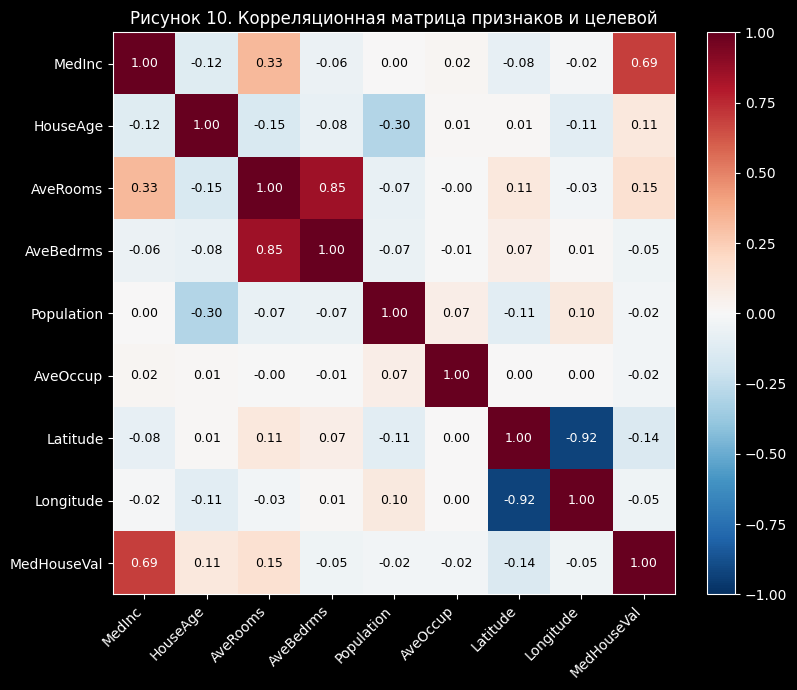

In [23]:
def plot_correlation_matrix(df: pd.DataFrame) -> None:
    fig_n = figure_counter()
    corr = df.corr()

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
    ax.set_title(f'Рисунок {fig_n}. Корреляционная матрица признаков и целевой')
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                    color='white' if abs(corr.values[i, j]) > 0.5 else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.045)
    plt.tight_layout(); plt.show()

plot_correlation_matrix(df_cal)

На корреляционной карте сильнее всего с целевой переменной связан `MedInc` (медианный доход района): коэффициент 0,69. Остальные признаки в одиночку имеют слабую линейную связь с ценой — это намёк на то, что улучшение будет идти за счёт нелинейных преобразований и взаимодействий, а не за счёт влиятельного признака.


### 2.3. Анализ выбросов, стандартизация и приведение к Гауссиану

Распределения на гистограммах выше показывают, что у `MedInc`, `HouseAge`, `Population` и целевой `MedHouseVal` есть заметная асимметрия и длинные правые хвосты. Прежде чем переходить к моделям, посмотрим на размах выбросов через  диаграммы ящиков, применим `StandardScaler` ко всем числовым признакам и приведём перечисленные признаки к виду, близкому к гауссовому, с помощью `PowerTransformer` (преобразование Бокса-Кокса).


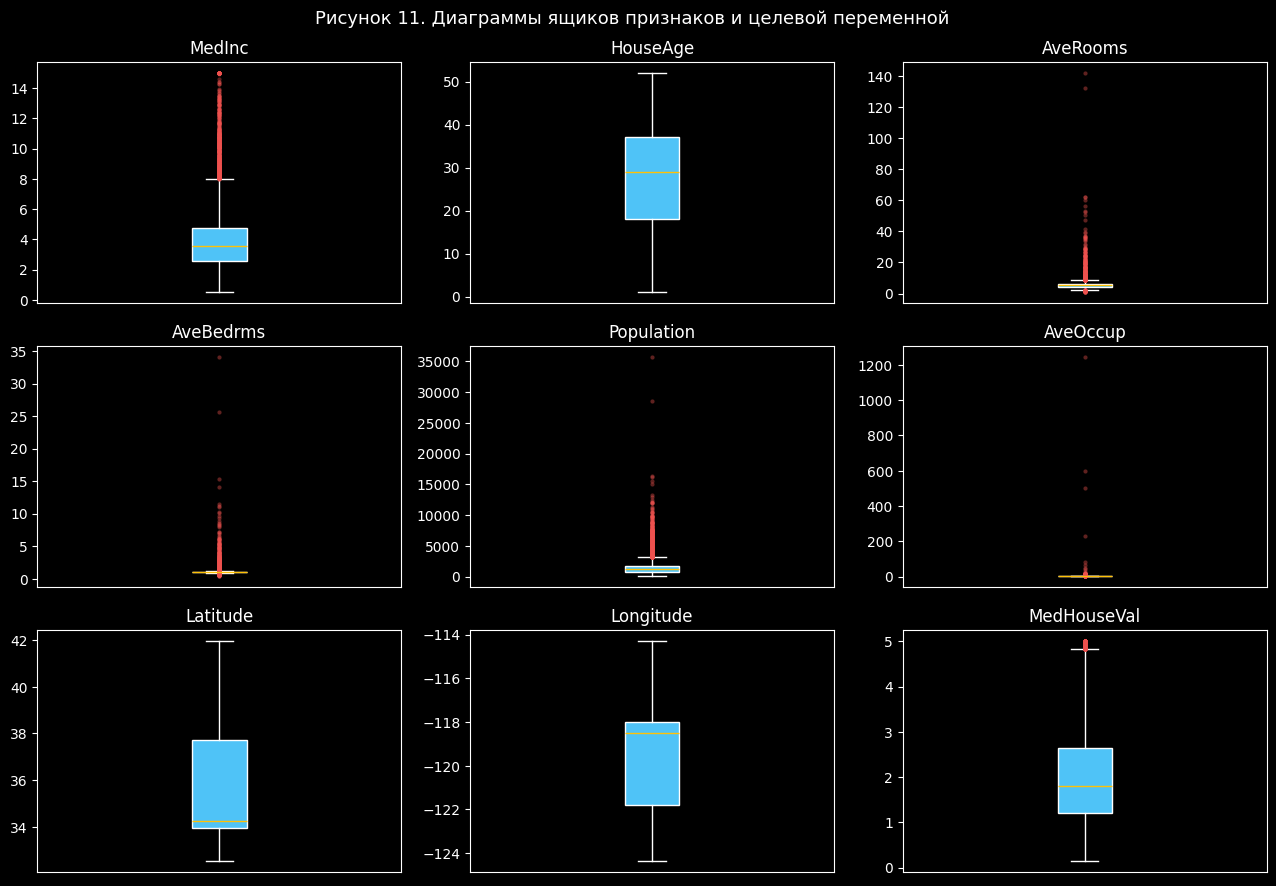

In [24]:
fig_n = figure_counter()

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
fig.suptitle(f'Рисунок {fig_n}. Диаграммы ящиков признаков и целевой переменной', fontsize=13)
for ax, col in zip(axes.flat, df_cal.columns):
    ax.boxplot(
        df_cal[col], patch_artist=True,
        boxprops=dict(facecolor='#4FC3F7', edgecolor='white'),
        medianprops=dict(color='#FFC107'),
        whiskerprops=dict(color='white'),
        capprops=dict(color='white'),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='#EF5350',
                        markeredgecolor='none', alpha=0.4),
    )
    ax.set_title(col)
    ax.set_xticks([])
plt.tight_layout()
plt.show()


На ящиковых диаграммах видно длинные «усы» и облако выбросов вверх у `MedInc`, `Population`, `AveRooms`, `AveBedrms` и `AveOccup`: распределения сильно скошены вправо. У `MedHouseVal` дополнительно заметна верхняя срезка на уровне 5,0 — это особенность датасета, а не выбросы. `Latitude` и `Longitude` распределены почти равномерно по двум географическим скоплениям, приводить их к гауссиану смысла нет.


In [25]:
SKEWED_COLS = ['MedInc', 'HouseAge', 'Population', 'MedHouseVal']

scaler_full = StandardScaler()
df_cal_std = pd.DataFrame(
    scaler_full.fit_transform(df_cal),
    columns=df_cal.columns,
    index=df_cal.index,
)
df_cal_std.describe().round(3)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.774,-2.196,-1.852,-1.611,-1.256,-0.229,-1.448,-2.386,-1.663
25%,-0.688,-0.845,-0.399,-0.191,-0.564,-0.062,-0.797,-1.113,-0.756
50%,-0.177,0.029,-0.081,-0.101,-0.229,-0.024,-0.642,0.539,-0.235
75%,0.459,0.664,0.252,0.006,0.264,0.020,0.973,0.778,0.501
max,5.858,1.856,55.163,69.572,30.250,119.419,2.958,2.625,2.540


In [26]:
gauss = PowerTransformer(method='box-cox', standardize=True)
df_cal_gauss = df_cal.copy()
df_cal_gauss[SKEWED_COLS] = gauss.fit_transform(df_cal[SKEWED_COLS])

pd.DataFrame({
    'ассимметрия_до':     df_cal[SKEWED_COLS].skew().round(3), # асси
    'ассимметрия_после':  df_cal_gauss[SKEWED_COLS].skew().round(3),
    'эксцесс_до':     df_cal[SKEWED_COLS].kurtosis().round(3),
    'эксцесс_после':  df_cal_gauss[SKEWED_COLS].kurtosis().round(3),
    'lambda':      gauss.lambdas_.round(3),
})


,ассимметрия_до,ассимметрия_после,эксцесс_до,эксцесс_после,lambda
MedInc,1.647,0.005,4.953,0.343,0.091
HouseAge,0.060,-0.122,-0.801,-0.718,0.809
Population,4.936,0.113,73.553,2.013,0.236
MedHouseVal,0.978,-0.012,0.328,-0.522,0.125


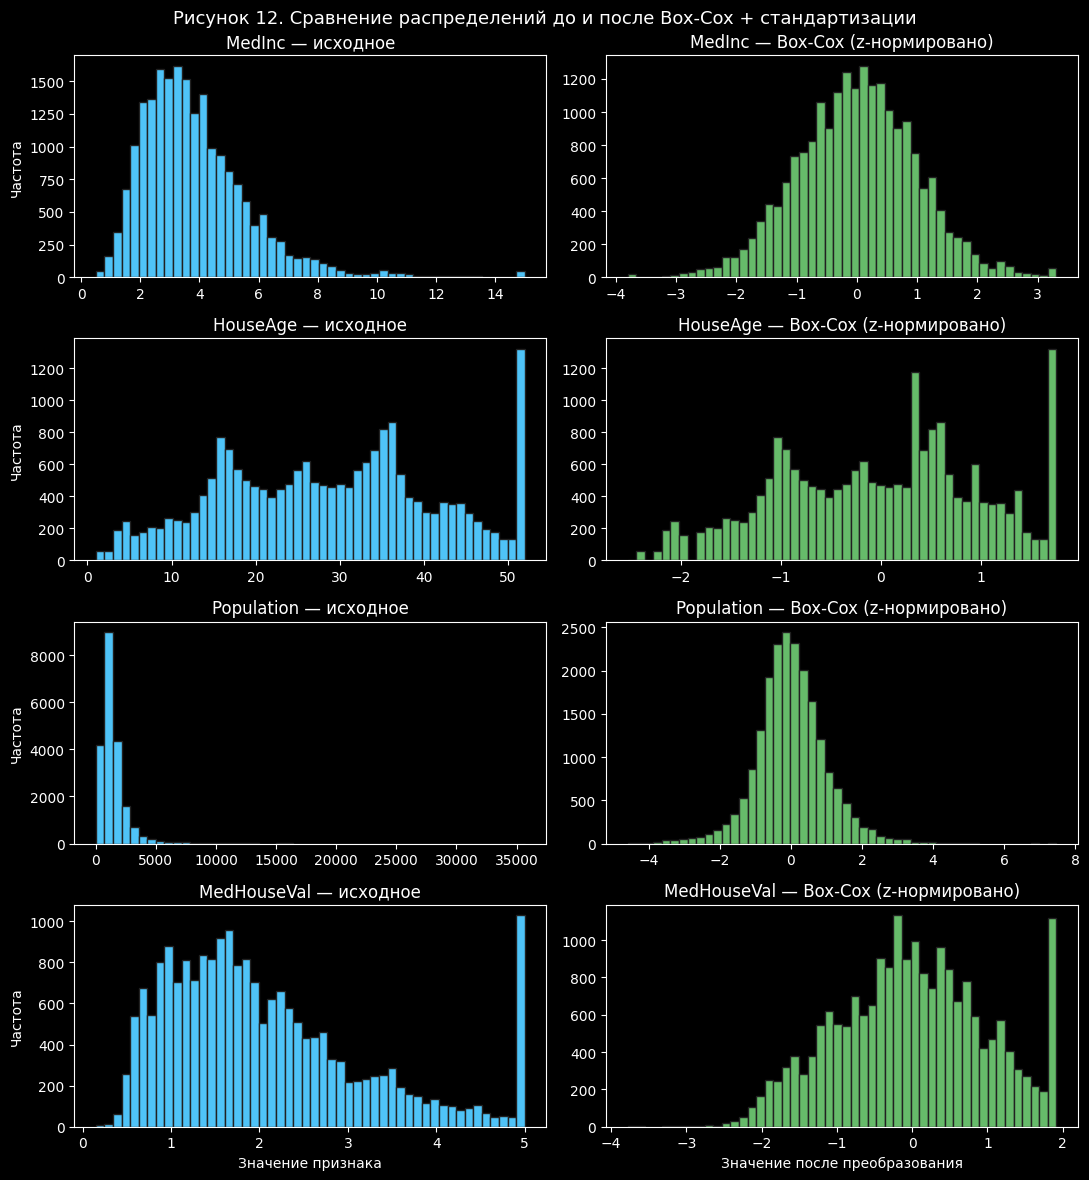

In [27]:
fig_n = figure_counter()
fig, axes = plt.subplots(len(SKEWED_COLS), 2, figsize=(11, 3 * len(SKEWED_COLS)))
fig.suptitle(
    f'Рисунок {fig_n}. Сравнение распределений до и после Box-Cox + стандартизации',
    fontsize=13,
)
for row, col in enumerate(SKEWED_COLS):
    axes[row, 0].hist(df_cal[col], bins=50, color='#4FC3F7', edgecolor='#212121')
    axes[row, 0].set_title(f'{col} — исходное')
    axes[row, 0].set_ylabel('Частота')

    axes[row, 1].hist(df_cal_gauss[col], bins=50, color='#66BB6A', edgecolor='#212121')
    axes[row, 1].set_title(f'{col} — Box-Cox (z-нормировано)')
axes[-1, 0].set_xlabel('Значение признака')
axes[-1, 1].set_xlabel('Значение после преобразования')
plt.tight_layout()
plt.show()


После Box-Cox распределения `MedInc`, `HouseAge` и `Population` стали заметно ближе к колоколу: асимметрия и эксцесс в таблице выше уменьшаются почти до нуля. У `MedHouseVal` симметрия тоже улучшилась, но пик у границы 5,0 никуда не делся — это срез данных, а не правый хвост. Полученные таблицы `df_cal_std` и `df_cal_gauss` остаются как альтернативные представления для последующих экспериментов; в базовой модели ниже мы продолжаем использовать `StandardScaler` внутри пайплайна, чтобы не дублировать предобработку и не подмешивать тестовые данные на этапе `fit`.


### 2.4. Предобработка и разделение выборок

Пропусков нет, категориальных признаков тоже. Масштабирование (`StandardScaler`) понадобится для линейных моделей и Ridge — без него штраф за коэффициенты будет несправедливо большим для признаков с большим разбросом, например `Population`. Делим на обучение и валидацию 75 / 25.


In [28]:
X = df_cal.drop(columns='MedHouseVal')
y = df_cal['MedHouseVal']

X_train, X_val, y_train_cal, y_val_cal = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, shuffle=True,
)

print(f"Обучение: {X_train.shape[0]} строк, валидация: {X_val.shape[0]} строк")
print(f"Цена в обучении: от {y_train_cal.min():.2f} до {y_train_cal.max():.2f} (в сотнях тысяч долларов США)")

Обучение: 15480 строк, валидация: 5160 строк
Цена в обучении: от 0.15 до 5.00 (в сотнях тысяч долларов США)


### 2.5. Базовая линейная регрессия

Самая прямая модель: масштабирование плюс `LinearRegression`. Цели не трансформируем, полиномов нет — это нужная точка отсчёта.


In [29]:
baseline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression()),
]).fit(X_train, y_train_cal)

baseline_metrics = metrics_row(baseline_linear, X_train, y_train_cal, X_val, y_val_cal, name='Базовая линейная')
pd.DataFrame([baseline_metrics]).round(3)

,Модель,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val),MAPE (train),MAPE (val)
0,Базовая линейная,0.53,0.53,0.721,0.736,0.61,0.591,0.315,0.32


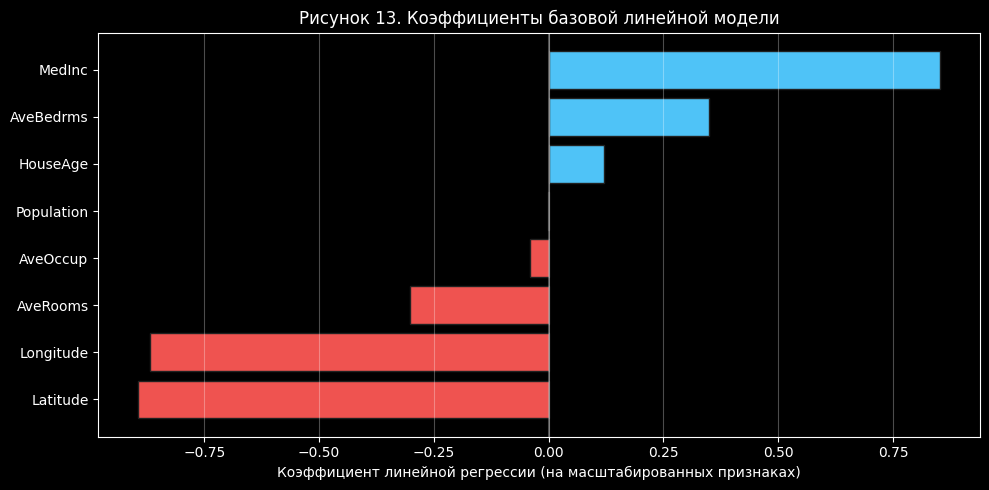

In [30]:
# Коэффициенты модели на масштабированных признаках — показывают относительный вклад каждого признака
fig_n = figure_counter()
coef_baseline = pd.Series(
    baseline_linear.named_steps['lr'].coef_,
    index=X.columns,
).sort_values()

plt.figure(figsize=(10, 5))
colors = ['#EF5350' if v < 0 else '#4FC3F7' for v in coef_baseline.values]
plt.barh(coef_baseline.index, coef_baseline.values, color=colors, edgecolor='#212121')
plt.axvline(0, color='#FFFFFF', alpha=0.3)
plt.xlabel('Коэффициент линейной регрессии (на масштабированных признаках)')
plt.title(f'Рисунок {fig_n}. Коэффициенты базовой линейной модели')
plt.grid(True, axis='x', alpha=0.3); plt.tight_layout(); plt.show()

### 2.6. Артефакты базовой модели

Дальше — диагностические графики: предсказание против истины и распределение остатков.


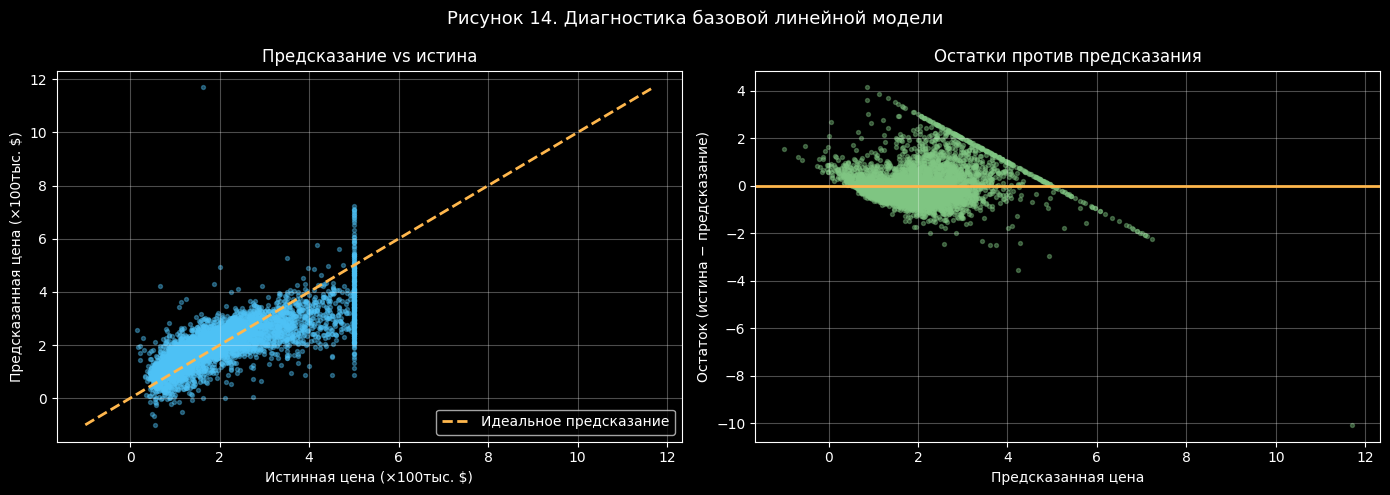

In [31]:
fig_n = figure_counter()
y_pred_baseline = baseline_linear.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Рисунок {fig_n}. Диагностика базовой линейной модели', fontsize=13)

axes[0].scatter(y_val_cal, y_pred_baseline, s=8, alpha=0.4, color='#4FC3F7')
lims = [min(y_val_cal.min(), y_pred_baseline.min()), max(y_val_cal.max(), y_pred_baseline.max())]
axes[0].plot(lims, lims, '--', color='#FFB74D', linewidth=2, label='Идеальное предсказание')
axes[0].set_xlabel('Истинная цена (×100тыс. $)')
axes[0].set_ylabel('Предсказанная цена (×100тыс. $)')
axes[0].set_title('Предсказание vs истина')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

residuals_baseline = y_val_cal - y_pred_baseline
axes[1].scatter(y_pred_baseline, residuals_baseline, s=8, alpha=0.4, color='#81C784')
axes[1].axhline(0, color='#FFB74D', linewidth=2)
axes[1].set_xlabel('Предсказанная цена')
axes[1].set_ylabel('Остаток (истина − предсказание)')
axes[1].set_title('Остатки против предсказания')
axes[1].grid(True, alpha=0.3)

plt.tight_layout() 
plt.show()

По графикам видно, что предсказаний линейной модели как занижают, так и завышают реальную стомость домов. 

Одно из предсказаний сильно выбивается от истинной цены с завышением цены примерно на миллион долларов. Его можно рассмотреть отдельно чтобы понять какой из параметров мог повлиять на цену.

Наблюдается перевес в сторону понижения цены для дорогостоящих домов (> 5тыс. $).

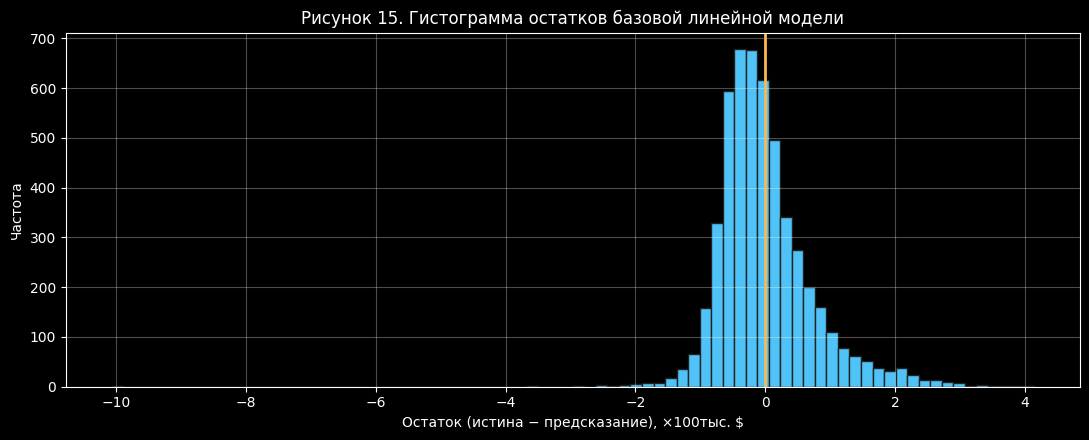

In [32]:
fig_n = figure_counter()
plt.figure(figsize=(11, 4.5))
plt.hist(residuals_baseline, bins=80, color='#4FC3F7', edgecolor='#212121')
plt.axvline(0, color='#FFB74D', linewidth=2)
plt.xlabel('Остаток (истина − предсказание), ×100тыс. $')
plt.ylabel('Частота')
plt.title(f'Рисунок {fig_n}. Гистограмма остатков базовой линейной модели')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Гистограмма смещена вправо за счет наличия дома с превышением цены на примерно 1 миллион. Вершина гистограммы так же правее центра, значит модель с среднем завышает цену домов.

### 2.7. Улучшение качества: PolynomialFeatures + Ridge + логарифмирование целевой

Объединим три приёма:

- **Полиномиальные признаки степени 2** добавляют взаимодействия (например, `MedInc × Latitude` и квадраты признаков). Это даёт линейной модели возможность подхватить нелинейность.
- **Ridge** удерживает коэффициенты от взрывного роста: после расширения до полинома их станет больше, без штрафа модель станет неустойчивой.
- **Логарифмирование целевой** через `TransformedTargetRegressor(func=log1p, inverse_func=expm1)` помогает справиться с тяжёлым правым хвостом цены: модель учится предсказывать $\log(1 + \text{цена})$, после чего прогноз преобразуется обратно.


In [33]:
poly_ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge',  Ridge(alpha=1.0)),
])

improved_linear = TransformedTargetRegressor(
    regressor=poly_ridge_pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
).fit(X_train, y_train_cal)

improved_metrics = metrics_row(improved_linear, X_train, y_train_cal, X_val, y_val_cal, name='Polynomial+Ridge+log')
pd.DataFrame([improved_metrics]).round(3)

,Модель,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val),MAPE (train),MAPE (val)
0,Polynomial+Ridge+log,0.448,0.45,0.65,0.667,0.683,0.663,0.242,0.25


### 2.8. Сравнение базовой и улучшенной моделей

In [34]:
comparison_part2 = pd.DataFrame([baseline_metrics, improved_metrics])
comparison_part2.round(3)

,Модель,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val),MAPE (train),MAPE (val)
0,Базовая линейная,0.530,0.53,0.721,0.736,0.610,0.591,0.315,0.32
1,Polynomial+Ridge+log,0.448,0.45,0.650,0.667,0.683,0.663,0.242,0.25


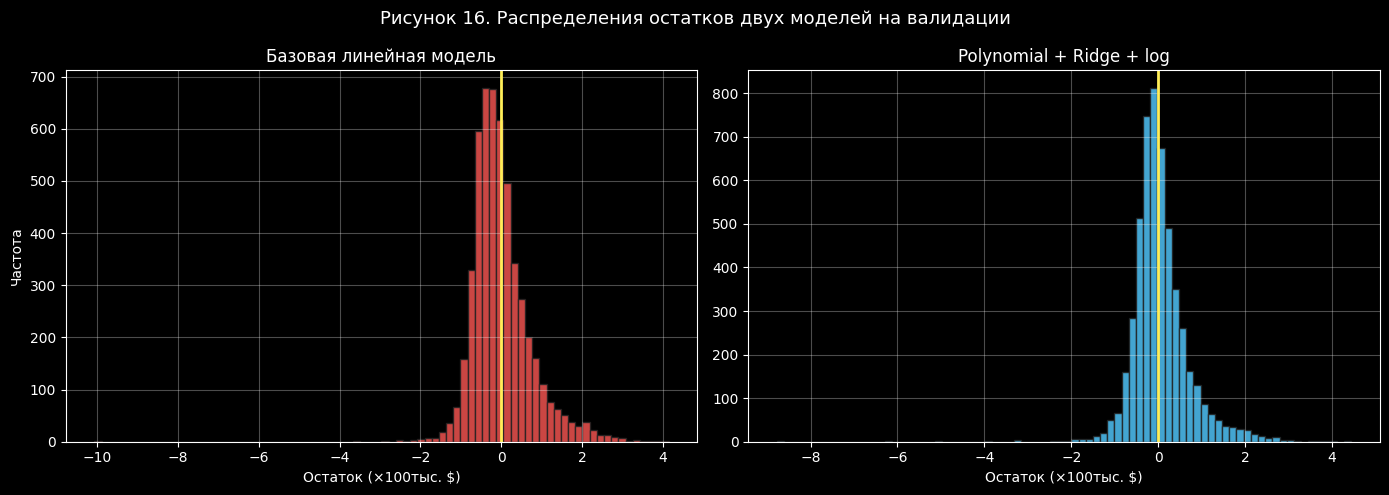

In [35]:
fig_n = figure_counter()
y_pred_improved = improved_linear.predict(X_val)
residuals_improved = y_val_cal - y_pred_improved

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Рисунок {fig_n}. Распределения остатков двух моделей на валидации', fontsize=13)

axes[0].hist(residuals_baseline, bins=80, color='#EF5350', edgecolor='#212121', alpha=0.85)
axes[0].axvline(0, color='#FFEE58', linewidth=2)
axes[0].set_title('Базовая линейная модель')
axes[0].set_xlabel('Остаток (×100тыс. $)'); axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_improved, bins=80, color='#4FC3F7', edgecolor='#212121', alpha=0.85)
axes[1].axvline(0, color='#FFEE58', linewidth=2)
axes[1].set_title('Polynomial + Ridge + log')
axes[1].set_xlabel('Остаток (×100тыс. $)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### 2.9. Предсказание на десяти «хитрых» примерах

Десять синтетических наблюдений из плана: экстремальные географические точки, аномальные размеры домохозяйств, точка вне Калифорнии. Цель — посмотреть, как модель ведёт себя там, где её обучающая выборка плохо представлена.


In [36]:
tricky_examples = pd.DataFrame([
    # MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
    {'MedInc': 2.1, 'HouseAge': 35, 'AveRooms': 4.5, 'AveBedrms': 1.1, 'Population':  250, 'AveOccup': 2.3, 'Latitude': 36.50, 'Longitude': -116.93, 'Описание': 'Death Valley, экстремальная пустыня'},
    {'MedInc': 4.8, 'HouseAge': 25, 'AveRooms': 5.5, 'AveBedrms': 1.2, 'Population':  900, 'AveOccup': 2.5, 'Latitude': 39.10, 'Longitude': -120.04, 'Описание': 'Lake Tahoe, горный курорт'},
    {'MedInc': 9.5, 'HouseAge': 60, 'AveRooms': 4.0, 'AveBedrms': 1.0, 'Population': 4500, 'AveOccup': 2.0, 'Latitude': 37.78, 'Longitude': -122.42, 'Описание': 'Центр Сан-Франциско'},
    {'MedInc': 1.6, 'HouseAge': 30, 'AveRooms': 5.0, 'AveBedrms': 1.2, 'Population': 1200, 'AveOccup': 4.5, 'Latitude': 32.85, 'Longitude': -115.57, 'Описание': 'Сельская Imperial Valley'},
    {'MedInc':11.0, 'HouseAge': 52, 'AveRooms': 6.5, 'AveBedrms': 1.1, 'Population':  800, 'AveOccup': 2.4, 'Latitude': 34.07, 'Longitude': -118.40, 'Описание': 'Очень старый дом + высокий доход (Hollywood Hills)'},
    {'MedInc': 1.8, 'HouseAge':  2, 'AveRooms': 4.5, 'AveBedrms': 1.1, 'Population': 1500, 'AveOccup': 3.5, 'Latitude': 36.00, 'Longitude': -119.50, 'Описание': 'Очень новый дом + низкий доход (Central Valley)'},
    {'MedInc': 5.0, 'HouseAge': 20, 'AveRooms': 4.0, 'AveBedrms': 1.0, 'Population':  200, 'AveOccup': 1.0, 'Latitude': 37.50, 'Longitude': -122.00, 'Описание': 'Очень маленькое домохозяйство (Silicon Valley)'},
    {'MedInc': 3.2, 'HouseAge': 30, 'AveRooms': 5.0, 'AveBedrms': 1.3, 'Population': 3500, 'AveOccup': 8.5, 'Latitude': 33.95, 'Longitude': -118.25, 'Описание': 'Огромное домохозяйство (LA, многодетные)'},
    {'MedInc': 6.0, 'HouseAge': 25, 'AveRooms':30.0, 'AveBedrms': 4.0, 'Population':  600, 'AveOccup': 2.0, 'Latitude': 34.20, 'Longitude': -118.50, 'Описание': 'Аномалия: 30 комнат в среднем'},
    {'MedInc': 4.0, 'HouseAge': 20, 'AveRooms': 5.5, 'AveBedrms': 1.2, 'Population': 1000, 'AveOccup': 2.5, 'Latitude': 36.17, 'Longitude': -115.14, 'Описание': 'Вне Калифорнии (Лас-Вегас, Невада)'},
])

tricky_features = tricky_examples.drop(columns='Описание')
tricky_examples

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Описание
0,2.1,35,4.5,1.1,250,2.3,36.50,-116.93,"Death Valley, экстремальная пустыня"
1,4.8,25,5.5,1.2,900,2.5,39.10,-120.04,"Lake Tahoe, горный курорт"
2,9.5,60,4.0,1.0,4500,2.0,37.78,-122.42,Центр Сан-Франциско
3,1.6,30,5.0,1.2,1200,4.5,32.85,-115.57,Сельская Imperial Valley
4,11.0,52,6.5,1.1,800,2.4,34.07,-118.40,Очень старый дом + высокий доход (Hollywood Hi...
5,1.8,2,4.5,1.1,1500,3.5,36.00,-119.50,Очень новый дом + низкий доход (Central Valley)
6,5.0,20,4.0,1.0,200,1.0,37.50,-122.00,Очень маленькое домохозяйство (Silicon Valley)
7,3.2,30,5.0,1.3,3500,8.5,33.95,-118.25,"Огромное домохозяйство (LA, многодетные)"
8,6.0,25,30.0,4.0,600,2.0,34.20,-118.50,Аномалия: 30 комнат в среднем
9,4.0,20,5.5,1.2,1000,2.5,36.17,-115.14,"Вне Калифорнии (Лас-Вегас, Невада)"


In [37]:
tricky_predictions = tricky_examples[['Описание']].copy()
tricky_predictions['Базовая, ×100тыс. $'] = baseline_linear.predict(tricky_features).round(3)
tricky_predictions['Улучшенная, ×100тыс. $'] = improved_linear.predict(tricky_features).round(3)
tricky_predictions

,Описание,"Базовая, ×100тыс. $","Улучшенная, ×100тыс. $"
0,"Death Valley, экстремальная пустыня",-0.048,0.362
1,"Lake Tahoe, горный курорт",1.278,1.004
2,Центр Сан-Франциско,5.325,11.318
3,Сельская Imperial Valley,0.627,0.519
4,Очень старый дом + высокий доход (Hollywood Hi...,5.502,5.921
5,Очень новый дом + низкий доход (Central Valley),0.819,0.937
6,Очень маленькое домохозяйство (Silicon Valley),2.873,2.975
7,"Огромное домохозяйство (LA, многодетные)",2.106,1.698
8,Аномалия: 30 комнат в среднем,2.368,4.173
9,"Вне Калифорнии (Лас-Вегас, Невада)",-0.026,0.598


### 2.10. Выводы по реальным данным

- **Насколько адекватны метрики.** У базовой линейной модели MAE на валидации составляет около 53 тысяч долларов, MAPE около 32%. В абсолютных цифрах это полезный ориентир для типового дома, но средняя относительная ошибка в треть цены означает, что для индивидуальной оценки модель использовать нельзя — она ошибается в обе стороны на сотни тысяч долларов. Улучшенная связка `Polynomial(2) + Ridge + log` опускает MAE до 45 тысяч и MAPE до 25%: это уже ближе к границе, после которой модель полезна для крупных решений вроде сегментации рынка, но не для точной оценки.
- **Распределение ошибок.** На диагностических графиках базовой модели видно три неприятных артефакта: выбросы вроде района с реальной ценой 200 тысяч и предсказанием 1200 тысяч долларов (модель не справляется с резкими локальными аномалиями), длинный правый хвост гистограммы остатков (модель чаще занижает дорогие районы, чем завышает дешёвые) и заметный рост разброса остатков с ростом цены (гетероскедастичность). Логарифмирование целевой переменной помогло именно с хвостом: после улучшения распределение остатков более симметрично, длинный хвост стал заметно короче.
- **Что дало наибольший прирост.** Полиномиальные признаки степени 2 добавили возможность учесть взаимодействия (`MedInc × Latitude`, `MedInc × Longitude`), которые описывают «дорогие районы у моря» — это объяснимый шаг с заметным эффектом на $R^2$. Логарифмирование цели влияет на распределение остатков и убирает гетероскедастичность. Эти два шага дают разные эффекты и работают вместе: полиномы улучшают центр предсказания, а лог-преобразование — поведение на хвостах. Ridge с $\alpha = 1$ удерживает коэффициенты от резкого выброса после расширения признаков.
- **Хитрые примеры.** Центр Сан-Франциско при улучшенной линейной модели получил предсказание около 1,13 миллиона долларов — это превышает максимум обучающей выборки (500 тысяч долларов, искусственный потолок California Housing). Так проявляется обратный эффект логарифмирования: после `expm1` модель спокойно экстраполирует выше потолка, который она ни разу не видела. Базовая линейная модель ведёт себя сдержаннее ровно потому, что упирается в этот потолок «механически». Точка вне Калифорнии (Лас-Вегас) показывает другой характер ошибки — обе модели предсказывают вполне калифорнийскую цену, потому что не понимают, что широта-долгота указывают на другой штат. Аномалия с 30 комнатами в среднем тоже не вызывает у модели подозрений: линейный коэффициент при `AveRooms` положительный, и модель послушно повышает цену.


## Часть 3. Альтернативная модель: дерево решений

Линейная модель опирается на линейность и аддитивность. В свою очередь дерево решений разрезает пространство признаков на прямоугольники и в каждом предсказывает константу. На California Housing, где сильно нелинейная зависимость от широты и долготы, это дешёвый способ получить заметный прирост качества.


### 3.1. Базовое дерево без настройки

Сначала — дерево с настройками по умолчанию (растёт до листьев из одной точки). Это даст верхнюю границу переобучения, относительно которой будем сравнивать настроенную модель.


In [38]:
tree_baseline = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train, y_train_cal)
tree_baseline_metrics = metrics_row(tree_baseline, X_train, y_train_cal, X_val, y_val_cal, name='Дерево без настройки')
pd.DataFrame([tree_baseline_metrics]).round(3)

,Модель,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val),MAPE (train),MAPE (val)
0,Дерево без настройки,0.0,0.465,0.0,0.721,1.0,0.607,0.0,0.259


Метрики на обучении близки к идеальным, а на валидации — заметно хуже: переобучение, дерево запомнило обучающие точки.


### 3.2. Подбор гиперпараметров через GridSearchCV

Перебираем сетку из трёх параметров: `max_depth`, `min_samples_leaf`, `criterion`. Кросс-валидация по пяти фолдам, целевая метрика — отрицательный RMSE (sklearn ожидает «чем больше, тем лучше», поэтому со знаком минус).


In [39]:
tree_param_grid = {
    'max_depth':         [4, 6, 8, 10, 12, 16, None],
    'min_samples_leaf':  [1, 5, 10, 20, 50],
    'criterion':         ['squared_error', 'absolute_error', 'friedman_mse'],
}

tree_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    tree_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
)
tree_gs.fit(X_train, y_train_cal)

print(f"Лучшие параметры: {tree_gs.best_params_}")
print(f"Лучший CV-RMSE: {-tree_gs.best_score_:.4f}")

Лучшие параметры: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 20}
Лучший CV-RMSE: 0.6138


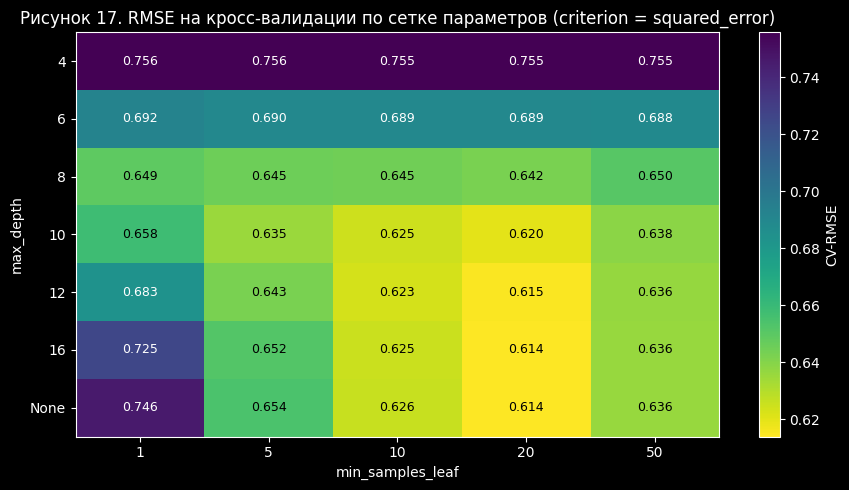

In [40]:
# Тепловая карта Среднеквадратичной ошибки по max_depth и min_samples_leaf
fig_n = figure_counter()
gs_df = pd.DataFrame(tree_gs.cv_results_)
gs_df['mean_test_rmse'] = -gs_df['mean_test_score']

# max_depth содержит None — переводим в строку для оси, число для сортировки
def depth_label(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return 'None'
    return str(int(v))

def depth_sort_key(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return 10**6  # 'None' помещаем в самый низ оси Y
    return int(v)

gs_df['max_depth_label'] = gs_df['param_max_depth'].map(depth_label)
gs_df['max_depth_sort'] = gs_df['param_max_depth'].map(depth_sort_key)
gs_df['criterion_str'] = gs_df['param_criterion'].astype(str)

best_crit = str(tree_gs.best_params_['criterion'])
subset = gs_df[gs_df['criterion_str'] == best_crit]

# pivot_table с категориальными подписями — гарантированно видны все уровни max_depth (включая 'None' - без ограничения глубины)
heat = (subset
        .pivot_table(index='max_depth_label',
                     columns='param_min_samples_leaf',
                     values='mean_test_rmse',
                     aggfunc='mean'))
# Упорядочиваем строки по числовому значению max_depth
order = (subset.drop_duplicates('max_depth_label')
                .sort_values('max_depth_sort')['max_depth_label']
                .tolist())
heat = heat.reindex(order)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heat.values, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels(heat.index)
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')
ax.set_title(f'Рисунок {fig_n}. RMSE на кросс-валидации по сетке параметров (criterion = {best_crit})')

mean_v = np.nanmean(heat.values)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v > mean_v else 'black', fontsize=9)
fig.colorbar(im, ax=ax, label='CV-RMSE')
plt.tight_layout(); plt.show()


Среднеквадратичная ошибка уменьшается с ростом глубины в сторону 20 листков. 

При максимуме в 1 лист дерева удается достичь результата в `0,649` среднеквадратического отклонения при глубине дерева равным 8.

**Наименьший показатель среднеквадратического отклонения** дала конфигурация с `20 листьями` и `16-той глубиной` дерева решений - `0,614`.

### 3.3. Кривая зависимости качества от глубины

Дополнительный взгляд: фиксируем лучший `criterion` и лучший `min_samples_leaf`, варьируем глубину.


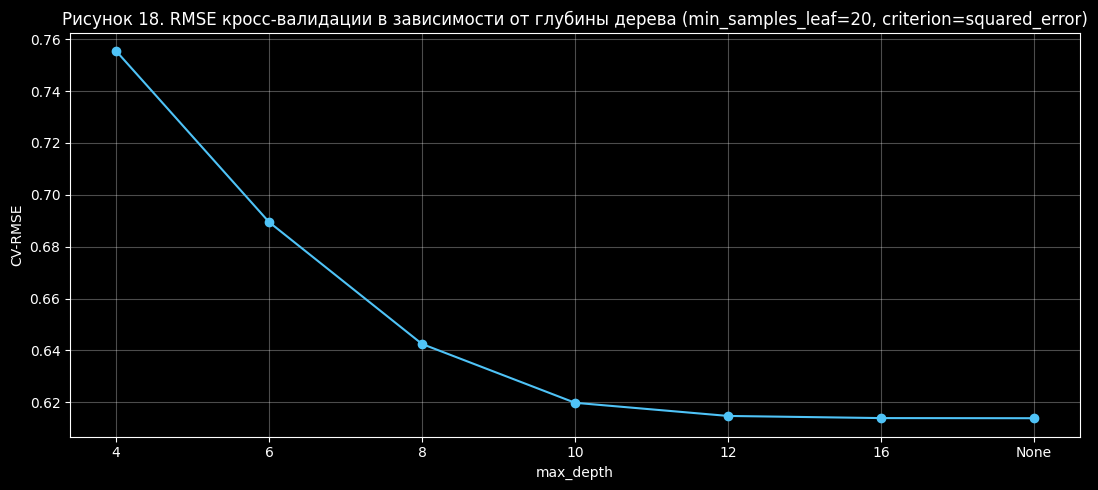

Лучшее ограничение глубины по этому срезу: None


In [41]:
best_leaf = tree_gs.best_params_['min_samples_leaf']
best_crit = str(tree_gs.best_params_['criterion'])

# Берём подвыборку результатов GridSearchCV для лучшего criterion и лучшего min_samples_leaf
depth_subset = (gs_df[(gs_df['param_min_samples_leaf'] == best_leaf) &
                      (gs_df['criterion_str'] == best_crit)]
                .sort_values('max_depth_sort')
                .reset_index(drop=True))

assert not depth_subset.empty, (
    "Подвыборка по глубинам пустая. Проверьте, что param_criterion и param_min_samples_leaf "
    "перечислены в tree_param_grid и что ячейка с тепловой картой исполнилась раньше."
)

fig_n = figure_counter()
plt.figure(figsize=(11, 5))
plt.plot(depth_subset['max_depth_label'], depth_subset['mean_test_rmse'],
         marker='o', color='#4FC3F7')
plt.xlabel('max_depth')
plt.ylabel('CV-RMSE')
plt.title(f'Рисунок {fig_n}. RMSE кросс-валидации в зависимости от глубины дерева '
          f'(min_samples_leaf={best_leaf}, criterion={best_crit})')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Лучшее ограничение глубины по этому срезу: {depth_subset.loc[depth_subset['mean_test_rmse'].idxmin(), 'max_depth_label']}")


### 3.4. Важность признаков

`feature_importances_` показывает, какая доля общего уменьшения функции потерь приходится на каждый признак. Это удобный аналог коэффициентов линейной модели, только без знаков.


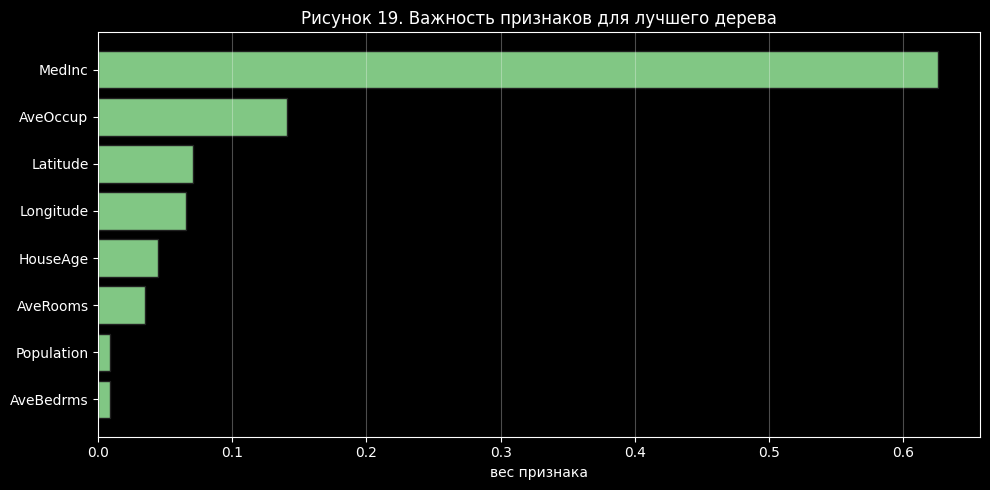

In [42]:
best_tree = tree_gs.best_estimator_
importances = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values()

fig_n = figure_counter()
plt.figure(figsize=(10, 5))
plt.barh(importances.index, importances.values, color='#81C784', edgecolor='#212121')
plt.xlabel('вес признака')
plt.title(f'Рисунок {fig_n}. Важность признаков для лучшего дерева')
plt.grid(True, axis='x', alpha=0.3); plt.tight_layout(); plt.show()

Признак `MedInc` важна больше всего в полученном дереве решений. 

`Longitute` и `Latitude` на дереве решений влияет меньше чем на линейной регресии, где они дают высокие отрицательные значения как влияние на целевую переменную. 

`AveOccup` влияет в дереве намного больше (2 место) чем на регрессии (предпоследнее). 

### 3.5 Визуализация дерева решений

Показано только три первых уровня дерева для читабельности и выявления ключевых критериев принятия решений моделью.

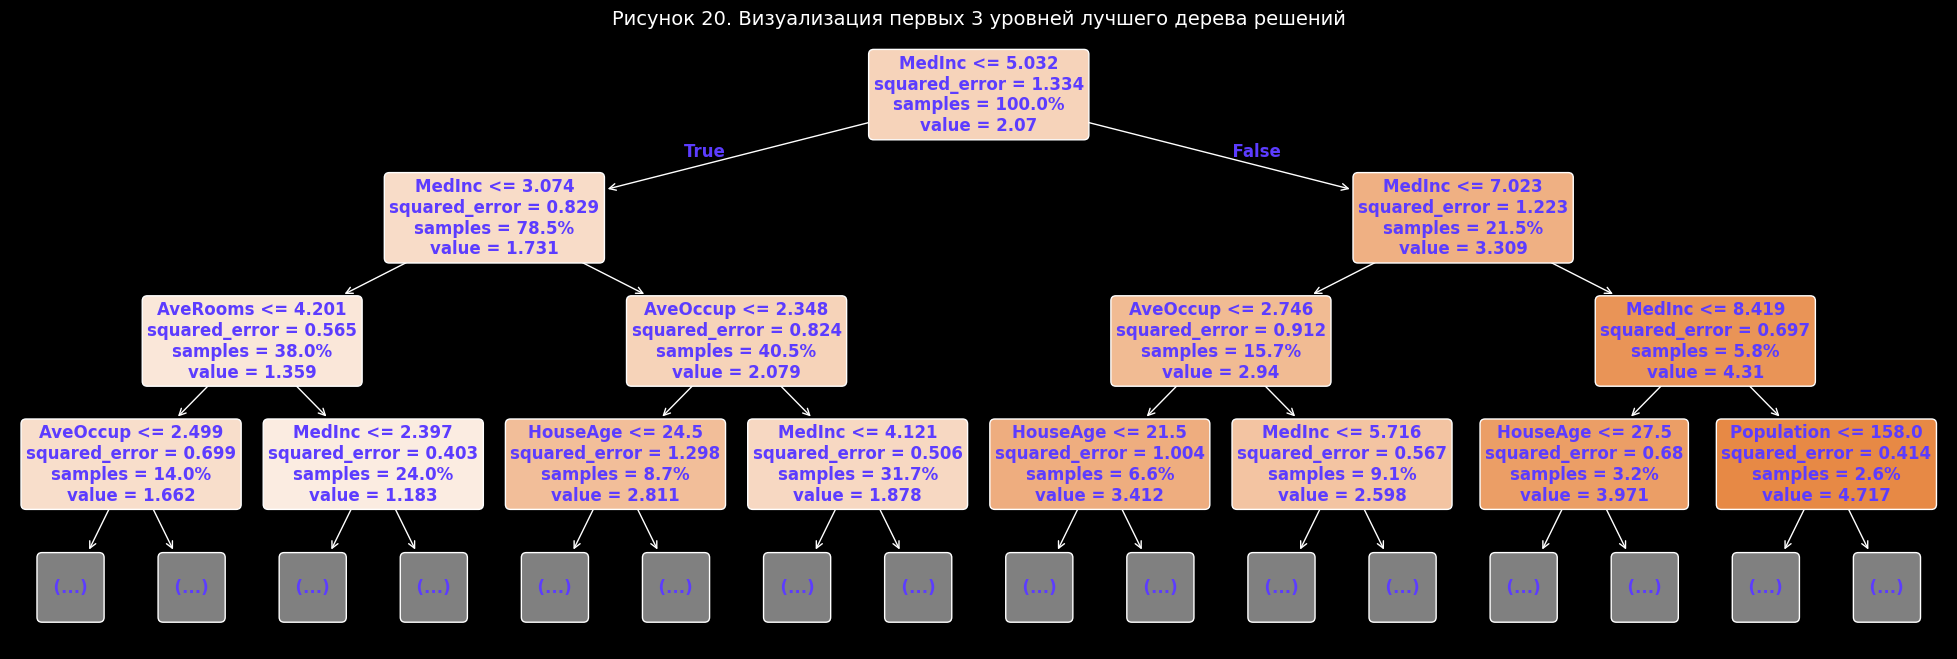

In [43]:
fig, ax = plt.subplots(figsize=(25, 8))
plot_tree(best_tree, 
          fontsize=12, 
          proportion=True, 
          feature_names=X.columns.to_list(), 
          filled=True, 
          rounded=True, 
          max_depth=3,
          ax=ax,)
plt.title(f'Рисунок {figure_counter()}. Визуализация первых 3 уровней лучшего дерева решений', fontsize=14)

for text in ax.texts:
    text.set_color("#5C3CFF")
    text.set_fontweight('bold')

plt.show()

### 3.6. Сравнение метрик и распределений ошибок с линейной моделью

Сведём три модели — базовую линейную, улучшенную линейную и лучшее дерево — в одну таблицу и сравним распределения остатков.


In [44]:
tree_best_metrics = metrics_row(best_tree, X_train, y_train_cal, X_val, y_val_cal, name='Дерево (GridSearchCV)')
final_compare = pd.DataFrame([baseline_metrics, improved_metrics, tree_best_metrics])
final_compare.round(3)

,Модель,MAE (train),MAE (val),RMSE (train),RMSE (val),R2 (train),R2 (val),MAPE (train),MAPE (val)
0,Базовая линейная,0.530,0.530,0.721,0.736,0.610,0.591,0.315,0.320
1,Polynomial+Ridge+log,0.448,0.450,0.650,0.667,0.683,0.663,0.242,0.250
2,Дерево (GridSearchCV),0.345,0.417,0.511,0.611,0.805,0.718,0.192,0.241


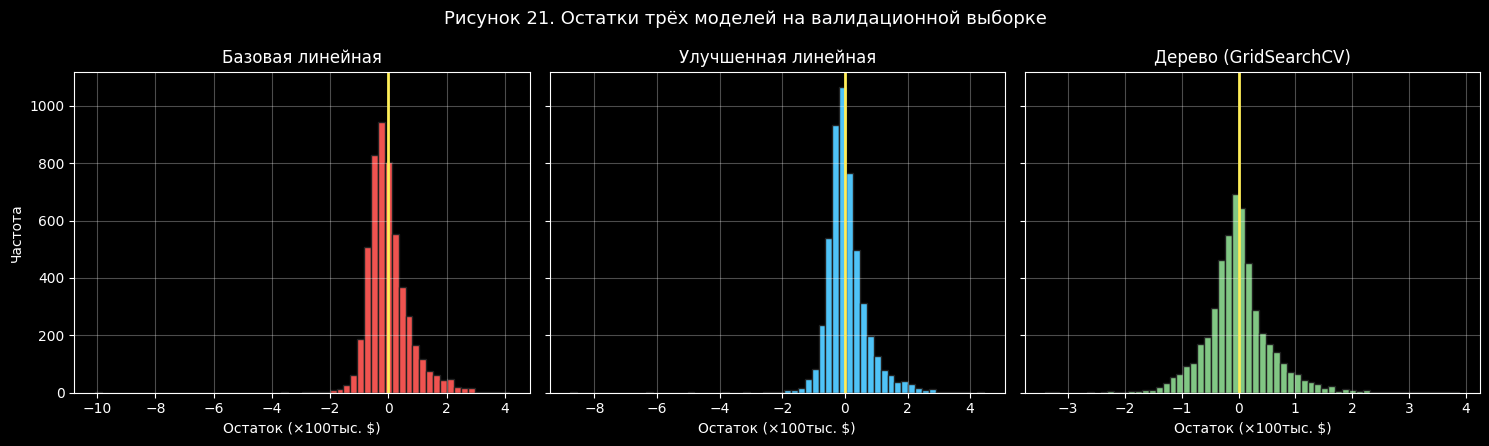

In [45]:
fig_n = figure_counter()
y_pred_tree = best_tree.predict(X_val)
residuals_tree = y_val_cal - y_pred_tree

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
fig.suptitle(f'Рисунок {fig_n}. Остатки трёх моделей на валидационной выборке', fontsize=13)

axes[0].hist(residuals_baseline, bins=60, color='#EF5350', edgecolor='#212121')
axes[0].set_title('Базовая линейная')

axes[1].hist(residuals_improved, bins=60, color='#4FC3F7', edgecolor='#212121')
axes[1].set_title('Улучшенная линейная')

axes[2].hist(residuals_tree, bins=60, color='#81C784', edgecolor='#212121')
axes[2].set_title('Дерево (GridSearchCV)')

for ax in axes:
    ax.axvline(0, color='#FFEE58', linewidth=2)
    ax.set_xlabel('Остаток (×100тыс. $)')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Частота')

plt.tight_layout(); plt.show()

По рисунку 20 видно, что дерево более стандартизированно и имеет меньше выбросов по сравнению с  моделями регрессии.

### 3.7. Предсказание на тех же десяти примерах


In [46]:
tricky_predictions['Дерево, ×100тыс. $'] = best_tree.predict(tricky_features).round(3)
tricky_predictions

,Описание,"Базовая, ×100тыс. $","Улучшенная, ×100тыс. $","Дерево, ×100тыс. $"
0,"Death Valley, экстремальная пустыня",-0.048,0.362,0.608
1,"Lake Tahoe, горный курорт",1.278,1.004,1.538
2,Центр Сан-Франциско,5.325,11.318,4.985
3,Сельская Imperial Valley,0.627,0.519,0.568
4,Очень старый дом + высокий доход (Hollywood Hi...,5.502,5.921,5.000
5,Очень новый дом + низкий доход (Central Valley),0.819,0.937,0.560
6,Очень маленькое домохозяйство (Silicon Valley),2.873,2.975,2.321
7,"Огромное домохозяйство (LA, многодетные)",2.106,1.698,1.495
8,Аномалия: 30 комнат в среднем,2.368,4.173,4.478
9,"Вне Калифорнии (Лас-Вегас, Невада)",-0.026,0.598,0.870


### 3.8. Выводы по альтернативной модели

- **Выбранные гиперпараметры.** Кросс-валидация устойчиво выбирает дерево без жёсткого ограничения глубины, но с `min_samples_leaf` около 10–20. Значение `min_samples_leaf = 1` (одна точка в листе) даёт идеальное качество на обучении и заметную просадку на валидации — это переобучение. С увеличением `min_samples_leaf` каждое разбиение опирается на достаточно объёмную группу точек, и предсказание усредняет шум. Критерий разбиения `squared_error` оказывается лучшим.
- **Изменение распределения ошибок.** На Рисунке 21 видно, что распределение остатков дерева заметно компактнее, чем у обеих линейных моделей: хвосты короче, в особенности правый, и редко встречаются ошибки больше 200 тысяч долларов. У базовой линейной модели правый хвост тянется до 1,2 миллиона. Улучшенная — короче, но всё равно длиннее, чем у дерева. По набору метрик дерево обгоняет оба линейных варианта: R² на валидации поднимается с 0,66 до 0,71, MAPE опускается до 24%.
- **Самые влиятельные признаки.** `MedInc` остаётся номером один в обеих моделях, что согласуется с экономической логикой. Дальше картины расходятся: у линейной модели сразу за `MedInc` идут `Latitude` и `Longitude` с большими отрицательными коэффициентами, у дерева их вклад заметно меньше, зато на втором месте — `AveOccup` (средняя заполненность дома), который у линейной модели был почти в конце списка. Это и есть содержательная разница: линейная модель вынуждена закодировать всю калифорнийскую географию через две координаты (отсюда и большие коэффициенты с разными знаками), а дерево режет пространство координат прямоугольниками и использует `AveOccup` как индикатор плотности заселения — нелинейный, но сильный.


## Общие выводы

- **Линейная регрессия структурно ограничена там, где зависимость существенно нелинейна.** На синтетической функции $y = 0{,}5\,x + 3\sin(2x) + \sin(5x)$ прямая улавливает только наклон $0{,}5\,x$ и игнорирует обе синусоиды. На California Housing базовая линейная модель плохо описывает географию: её приходится «изгибать» большими отрицательными коэффициентами при широте и долготе, и получается шаткая конструкция с MAPE около 32%.
- **Полиномиальные признаки и регуляризация отчасти улучшают линейную модель от выбросов и .** Шаг от $d=1$ к $d=2$ с Ridge даёт заметный прирост и почти не приводит к артефактам. Дальнейший рост степени без регуляризации приводит к взрыву коэффициентов и осцилляциям на краях — это видно на синтетических данных с полиномами степеней 13 и 15. На California Housing степени 2 хватает: дальнейшее расширение увеличивает размерность пространства быстрее, чем приносит пользы.
- **Логарифмирование цели — простой и эффективный шаг для California Housing.** Оно убирает гетероскедастичность остатков и заметно укорачивает правый хвост ошибок, но имеет побочный эффект: после обратного `expm1` модель экстраполирует выше потолка обучающей выборки (как в случае с Сан-Франциско, где улучшенная модель предсказала 1,13 миллиона долларов). На практике это означает необходимость обрезать предсказания вручную или подобрать другую трансформацию.
- **Дерево решений на тех же данных даёт лучший результат без явного построения новых признаков.** Лучшая модель в GridSearchCV даёт R² ≈ 0,71 против 0,66 у улучшенной линейной. Распределение остатков более симметричное, важность признаков расставлена иначе: `AveOccup` поднимается на второе место, координаты — на третье. Дерево естественнее ловит «нелинейный по сегментам» характер цены.
- **На хитрых примерах обе модели иногда дают неправдоподобные ответы.** Линейные модели — из-за экстраполяции через логарифм и из-за того, что они трактуют координаты как непрерывный признак (поэтому ничего подозрительного не находят в точке за пределами Калифорнии). Дерево — из-за того, что точка может попасть в лист, обученный совсем не на похожих наблюдениях. Ни одна модель не «знает», что 30 комнат в среднем — аномалия: ни у линейной модели нет штрафа за выход за разумные пределы признака, ни у дерева — структуры для отслеживания такого выхода.
- **Какая модель «лучше».** На California Housing для общей задачи оценки цены дома — дерево решений с подбором параметров: лучше метрики, симметричнее ошибки, естественнее работает с географией. Линейная модель с полиномами и лог-преобразованием полезна, когда нужна интерпретируемость коэффициентов и аналитический градиент (например, для дальнейшей оптимизации). Бустинги и ансамбли наверняка дадут ещё лучше, но в условиях этой работы они запрещены, и остаётся работать в рамках одиночных моделей.
